
# Metabolic Double-Bind Cancer Control
## A literature-benchmarked, synthetic proof-of-concept analysis of tumour metabolic plasticity, mitochondrial function, host fitness, nutrition-related metabolic pressure, and exercise

**Purpose.** This notebook is designed as a computational companion for a future review paper. It translates biochemical concepts into a falsifiable, quantitative framework using **synthetic data only**. It does **not** contain patient data and does **not** test or establish a cancer treatment.

### Central hypothesis

A more defensible metabolic strategy than nonspecific “cancer starvation” is:

> **Preserve host metabolic fitness while identifying and constraining tumour-specific fuel dependencies and escape pathways.**

The model therefore treats cancer as a heterogeneous metabolic system that may use glycolysis, oxidative phosphorylation (OXPHOS), glutamine, fatty acids, lactate exchange, one-carbon metabolism, and apoptosis-resistance mechanisms in different proportions.

### Important scientific boundary

The simulations below are **mechanistic thought experiments**, not clinical prescriptions. Numeric distributions are calibrated to directions, effect sizes, ranges, and biological relationships reported in peer-reviewed PubMed-indexed literature where possible, but they are not reconstructed patient-level data. Intervention variables represent abstract **metabolic pressures** rather than diet plans, drug doses, or treatment recommendations.



## Literature foundation and benchmark map

The notebook intentionally corrects the oversimplified statement that cancer cells universally have “broken mitochondria.” Aerobic glycolysis can occur despite functional mitochondria, and many cancers retain substantial OXPHOS and metabolic plasticity.

| Biological concept | Literature anchor used in the model | How it is represented |
|---|---|---|
| Warburg effect | Vander Heiden, Cantley & Thompson, *Science* (2009), PMID 19460998 | High glycolytic flux can coexist with mitochondrial respiration; glycolysis supports biomass as well as ATP |
| Broad metabolic reprogramming | Tufail et al. (2024), PMID 39294640 | Glycolysis, OXPHOS, glutaminolysis and lipid metabolism are all available tumour states |
| Metabolic plasticity | Masoudi et al. (2024), PMID 38599259 | Entropy-based fuel flexibility and compensatory rerouting |
| Lactate shuttle | Semenza (2008), PMID 19033652; Draoui & Feron (2011), PMID 22065843 | Lactate export/import and MCT-associated escape are represented as a plasticity modifier |
| ETC requirement for proliferation | Sullivan et al. (2015), PMID 26232224 | OXPHOS is treated as a biosynthetic/redox contributor, not only an ATP generator |
| Mitochondrial apoptosis | Palominos et al. (2024), PMID 38788967 | Respiratory capacity and apoptosis resistance are modeled as separable traits |
| Methionine/one-carbon metabolism | Gao et al., *Nature* (2019), PMID 31367041 | Methionine pressure affects biosynthesis/redox rather than ATP alone |
| Fasting-mimicking metabolic modulation | Vernieri et al. (2022), PMID 34789537 | Systemic glucose/growth-factor pressure is represented abstractly, without prescribing fasting |
| Exercise and outcomes | Courneya et al., *NEJM* (2025), PMID 40450658 | Structured exercise is represented as host-support; published trial benchmark: 5-y DFS 80.3% vs 73.9%, 8-y OS 90.3% vs 83.2% |
| Skeletal muscle metabolic importance | Baumert et al. (2024), PMID 38742477 | Lean mass and fitness increase host metabolic reserve |
| Cachexia risk | Shorter et al. (2024), PMID 38457901 | Low lean mass/nutritional reserve amplify host cost of nonspecific restriction |
| Ketogenic diet evidence uncertainty | Salido-Bueno et al. (2024), PMID 38923748 | No universal ketone intolerance is assumed; carbohydrate pressure is not treated as a cure |

### PubMed links

- https://pubmed.ncbi.nlm.nih.gov/19460998/
- https://pubmed.ncbi.nlm.nih.gov/39294640/
- https://pubmed.ncbi.nlm.nih.gov/38599259/
- https://pubmed.ncbi.nlm.nih.gov/19033652/
- https://pubmed.ncbi.nlm.nih.gov/22065843/
- https://pubmed.ncbi.nlm.nih.gov/26232224/
- https://pubmed.ncbi.nlm.nih.gov/38788967/
- https://pubmed.ncbi.nlm.nih.gov/31367041/
- https://pubmed.ncbi.nlm.nih.gov/34789537/
- https://pubmed.ncbi.nlm.nih.gov/40450658/
- https://pubmed.ncbi.nlm.nih.gov/38742477/
- https://pubmed.ncbi.nlm.nih.gov/38457901/
- https://pubmed.ncbi.nlm.nih.gov/38923748/

**Interpretive rule:** simulated values below are *literature-informed assumptions*. They are not claimed to be measured values from these publications.


In [1]:

from pathlib import Path
import math
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
from sklearn.inspection import permutation_importance

SEED = 42
rng = np.random.default_rng(SEED)

OUTPUT_DIR = Path("cancer_metabolic_double_bind_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (9, 6),
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11
})

def savefig(name):
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{name}.png", bbox_inches="tight")
    plt.savefig(OUTPUT_DIR / f"{name}.pdf", bbox_inches="tight")
    plt.show()

print("Output directory:", OUTPUT_DIR.resolve())


Output directory: /mnt/data/cancer_metabolic_double_bind_outputs



## 1. Benchmark assumptions used for simulation

The table below makes every major assumption explicit. Dimensionless variables are scaled from 0 to 1 because published studies use heterogeneous assays, tumour types, media, platforms and endpoints. This prevents false precision.

The exercise-survival values are retained in their published clinical units because they were directly reported in the randomized CHALLENGE trial. Other variables are calibrated as **relative mechanistic ranges**, not literal clinical reference intervals.


In [2]:

benchmarks = pd.DataFrame([
    ["Aerobic glycolysis", "Cancer can maintain high glycolysis despite oxygen and functional mitochondria", "dimensionless glycolysis score 0-1", "PMID:19460998"],
    ["Metabolic plasticity", "Tumours can switch among glycolysis, OXPHOS, amino-acid and lipid pathways", "entropy-derived flexibility 0-1", "PMID:38599259"],
    ["Lactate shuttle", "MCT1/MCT4-mediated lactate exchange can support metabolic symbiosis", "lactate-shuttle score 0-1", "PMID:19033652; PMID:22065843"],
    ["Mitochondrial function", "Cancer mitochondria can remain respiratory/biosynthetic", "mitochondrial capacity 0-1", "PMID:26232224; PMID:39294640"],
    ["Apoptosis resistance", "BCL-2 family control can uncouple death resistance from respiration", "apoptosis-resistance score 0-1", "PMID:38788967"],
    ["Methionine dependence", "MR perturbs one-carbon, nucleotide and redox metabolism; human pilot n=6", "methionine-dependence score 0-1", "PMID:31367041"],
    ["Exercise host support", "5-y DFS 80.3% vs 73.9%; 8-y OS 90.3% vs 83.2% in colon cancer trial", "host-support calibration only", "PMID:40450658"],
    ["Cachexia vulnerability", "Cancer-associated muscle dysfunction involves inflammation, proteostasis and mitochondrial changes", "host vulnerability 0-1", "PMID:38457901"],
    ["Ketogenic evidence", "Clinical evidence remains heterogeneous; no universal anti-tumour effect assumed", "carbohydrate pressure kept partial", "PMID:38923748"],
], columns=["Concept", "Evidence statement", "Simulation representation", "PubMed source"])

benchmarks


,Concept,Evidence statement,Simulation representation,PubMed source
0,Aerobic glycolysis,Cancer can maintain high glycolysis despite ox...,dimensionless glycolysis score 0-1,PMID:19460998
1,Metabolic plasticity,"Tumours can switch among glycolysis, OXPHOS, a...",entropy-derived flexibility 0-1,PMID:38599259
2,Lactate shuttle,MCT1/MCT4-mediated lactate exchange can suppor...,lactate-shuttle score 0-1,PMID:19033652; PMID:22065843
3,Mitochondrial function,Cancer mitochondria can remain respiratory/bio...,mitochondrial capacity 0-1,PMID:26232224; PMID:39294640
4,Apoptosis resistance,BCL-2 family control can uncouple death resist...,apoptosis-resistance score 0-1,PMID:38788967
5,Methionine dependence,"MR perturbs one-carbon, nucleotide and redox m...",methionine-dependence score 0-1,PMID:31367041
6,Exercise host support,5-y DFS 80.3% vs 73.9%; 8-y OS 90.3% vs 83.2% ...,host-support calibration only,PMID:40450658
7,Cachexia vulnerability,Cancer-associated muscle dysfunction involves ...,host vulnerability 0-1,PMID:38457901
8,Ketogenic evidence,Clinical evidence remains heterogeneous; no un...,carbohydrate pressure kept partial,PMID:38923748



## 2. Generate a virtual tumour-host cohort

Five metabolic archetypes are simulated:

1. **Glycolytic** — high glucose/glycolysis dependence.
2. **Glutamine-dependent** — greater glutaminolytic/TCA anaplerotic dependence.
3. **OXPHOS-dependent** — greater mitochondrial oxidative dependence.
4. **FAO/lipid-dependent** — greater fatty-acid oxidation/lipid dependence.
5. **Metabolically plastic** — relatively even access to several fuels.

For each virtual tumour we generate four normalized fuel dependencies summing to one. Plasticity is quantified using normalized Shannon entropy:

\[
P=-\frac{\sum_i p_i\ln p_i}{\ln 4}
\]

Thus, a tumour highly dependent on one fuel has lower \(P\), while a tumour able to distribute metabolism across several fuels has higher \(P\).

Host variables include skeletal lean mass, fitness, insulin sensitivity, nutritional reserve and cachexia vulnerability. These are synthetic covariates, included to make host protection an explicit part of the model.


In [3]:

N = 2400
phenotypes = np.array(["Glycolytic", "Glutamine", "OXPHOS", "FAO_lipid", "Plastic"])
phenotype = rng.choice(phenotypes, size=N, p=[0.24, 0.18, 0.20, 0.14, 0.24])

alpha_map = {
    "Glycolytic": np.array([7.0, 1.7, 2.0, 1.3]),
    "Glutamine":  np.array([2.0, 7.0, 2.2, 1.4]),
    "OXPHOS":     np.array([1.8, 2.0, 7.0, 1.8]),
    "FAO_lipid":  np.array([1.6, 1.5, 2.2, 7.0]),
    "Plastic":    np.array([3.4, 3.4, 3.4, 3.4]),
}

deps = np.vstack([rng.dirichlet(alpha_map[p]) for p in phenotype])
dep_cols = ["glucose_dep", "glutamine_dep", "oxphos_dep", "fatty_acid_dep"]

df = pd.DataFrame(deps, columns=dep_cols)
df["phenotype"] = phenotype

entropy = -(deps * np.log(deps + 1e-12)).sum(axis=1) / np.log(deps.shape[1])
df["plasticity"] = np.clip(entropy + rng.normal(0, 0.06, N), 0, 1)

# Tumour biology: intentionally allow mitochondrial competence and apoptosis resistance to vary independently.
df["mitochondrial_capacity"] = np.clip(
    0.20 + 0.72*df["oxphos_dep"] + 0.18*df["fatty_acid_dep"] + rng.normal(0, 0.12, N), 0, 1
)
df["glycolysis_score"] = np.clip(
    0.18 + 0.75*df["glucose_dep"] + 0.16*df["plasticity"] + rng.normal(0, 0.10, N), 0, 1
)
df["lactate_shuttle"] = np.clip(
    0.15 + 0.50*df["glycolysis_score"] + 0.28*df["plasticity"] + rng.normal(0, 0.12, N), 0, 1
)
df["methionine_dependence"] = np.clip(
    rng.beta(2.6, 2.1, N) + 0.10*df["glycolysis_score"] + rng.normal(0, 0.05, N), 0, 1
)
df["apoptosis_resistance"] = np.clip(
    rng.beta(2.8, 2.0, N) + rng.normal(0, 0.06, N), 0, 1
)
df["redox_demand"] = np.clip(
    0.25 + 0.36*df["glycolysis_score"] + 0.25*df["oxphos_dep"] + rng.normal(0, 0.10, N), 0, 1
)
df["biosynthetic_demand"] = np.clip(
    0.30 + 0.32*df["glycolysis_score"] + 0.24*df["glutamine_dep"] + rng.normal(0, 0.09, N), 0, 1
)

# Synthetic host system.
df["lean_mass_kg"] = np.clip(rng.normal(49, 9, N), 27, 78)
df["fitness_index"] = np.clip(rng.beta(3.0, 2.5, N), 0.05, 0.98)
df["insulin_sensitivity"] = np.clip(rng.beta(3.2, 2.4, N), 0.05, 0.98)
df["nutritional_reserve"] = np.clip(rng.beta(3.4, 2.2, N), 0.05, 0.99)

cachexia_latent = (
    0.50*(1 - (df["lean_mass_kg"]-27)/(78-27))
    + 0.35*(1-df["nutritional_reserve"])
    + 0.15*rng.random(N)
)
df["cachexia_vulnerability"] = np.clip(cachexia_latent, 0, 1)

# Illustrative systemic markers, not clinical reference intervals.
df["fasting_glucose_mmol_L"] = np.clip(
    4.5 + 2.0*(1-df["insulin_sensitivity"]) + rng.normal(0, 0.35, N), 3.6, 9.5
)
df["fasting_insulin_uU_mL"] = np.clip(
    4.0 + 13.0*(1-df["insulin_sensitivity"]) + rng.normal(0, 2.0, N), 1.5, 35
)
df["lactate_mM_proxy"] = np.clip(
    0.8 + 2.8*df["glycolysis_score"] + 0.9*df["lactate_shuttle"] + rng.normal(0, 0.35, N), 0.4, 5.5
)

df.head()


,glucose_dep,glutamine_dep,oxphos_dep,fatty_acid_dep,phenotype,plasticity,mitochondrial_capacity,glycolysis_score,lactate_shuttle,methionine_dependence,apoptosis_resistance,redox_demand,biosynthetic_demand,lean_mass_kg,fitness_index,insulin_sensitivity,nutritional_reserve,cachexia_vulnerability,fasting_glucose_mmol_L,fasting_insulin_uU_mL,lactate_mM_proxy
0,0.359377,0.247719,0.117526,0.275378,Plastic,0.905465,0.000000,0.427211,0.455000,1.000000,0.846996,0.343959,0.557359,65.207364,0.499013,0.365009,0.529751,0.322827,5.644078,15.354300,3.022586
1,0.164872,0.219636,0.275264,0.340228,OXPHOS,1.000000,0.447352,0.415953,0.469625,0.608904,0.492913,0.468197,0.301057,48.889455,0.557520,0.433189,0.418196,0.542009,5.497692,9.780360,2.293287
2,0.470923,0.151873,0.130311,0.246893,Plastic,0.990617,0.224895,0.819415,1.000000,0.680197,0.773072,0.587975,0.595578,69.039249,0.447810,0.868806,0.677692,0.322792,4.648283,2.367292,3.323205
3,0.085502,0.169581,0.181330,0.563587,FAO_lipid,0.878706,0.525622,0.318610,0.283302,0.804769,0.621773,0.496310,0.460787,66.891169,0.462417,0.391473,0.114356,0.501028,5.716090,12.501068,1.538502
4,0.397708,0.269631,0.038495,0.294166,Glycolytic,0.950364,0.406382,0.676900,0.810917,0.912046,0.217544,0.334535,0.557070,60.243495,0.624716,0.462477,0.614551,0.312910,5.438057,10.971747,2.826062


In [4]:

print("Synthetic cohort size:", len(df))
print("\nMetabolic phenotype distribution:")
print(df["phenotype"].value_counts().to_frame("n"))
print("\nMedian tumour and host characteristics:")
display(df[[
    "glycolysis_score","mitochondrial_capacity","plasticity","lactate_shuttle",
    "methionine_dependence","apoptosis_resistance","lean_mass_kg",
    "fitness_index","insulin_sensitivity","cachexia_vulnerability"
]].median().to_frame("median"))


Synthetic cohort size: 2400

Metabolic phenotype distribution:
              n
phenotype      
Plastic     595
Glycolytic  591
OXPHOS      483
Glutamine   431
FAO_lipid   300

Median tumour and host characteristics:


,median
glycolysis_score,0.490121
mitochondrial_capacity,0.422152
plasticity,0.816786
lactate_shuttle,0.632855
methionine_dependence,0.614462
apoptosis_resistance,0.599062
lean_mass_kg,48.663836
fitness_index,0.548613
insulin_sensitivity,0.578151
cachexia_vulnerability,0.497714



### Interpretation

The simulation deliberately produces **overlap**, not mutually exclusive metabolic states. A glycolytic tumour can still possess meaningful mitochondrial capacity. Likewise, an OXPHOS-dominant tumour can retain glycolytic reserve. This is the central reason a single universal fuel-deprivation strategy is biologically implausible.


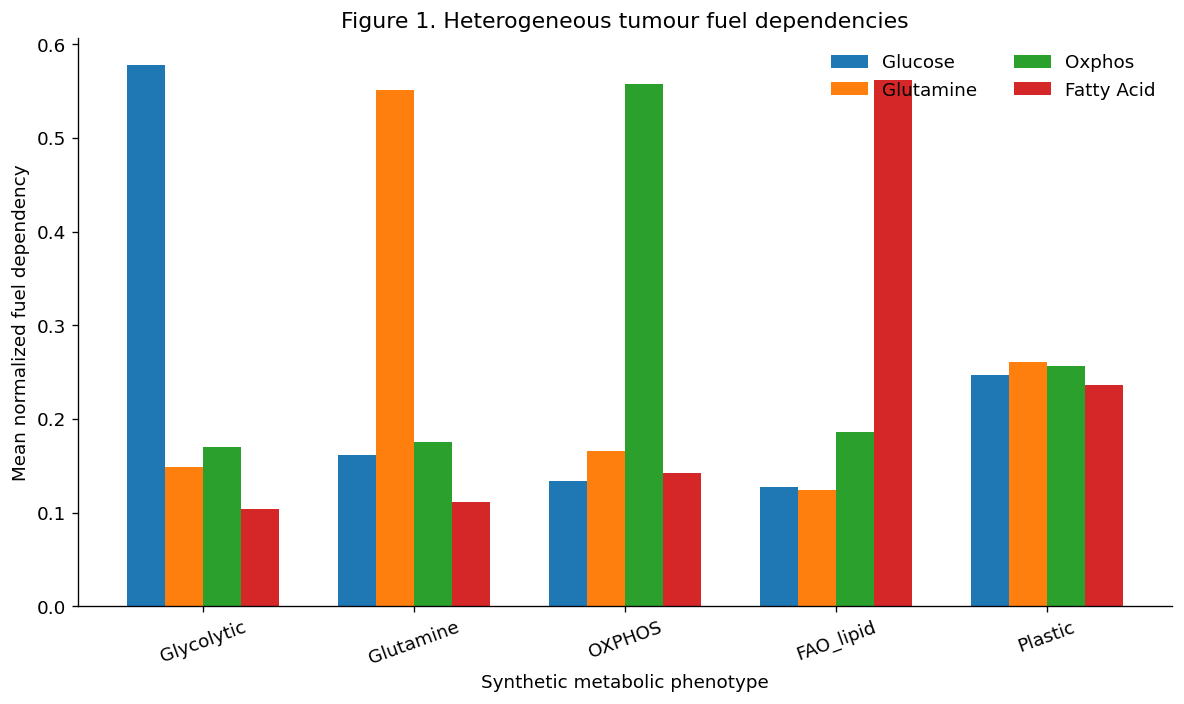

In [5]:

# Figure 1: metabolic dependency profiles
profile = df.groupby("phenotype")[dep_cols].mean().reindex(phenotypes)
x = np.arange(len(profile))
width = 0.18

plt.figure(figsize=(10, 6))
for i, col in enumerate(dep_cols):
    plt.bar(x + (i-1.5)*width, profile[col], width=width, label=col.replace("_dep","").replace("_"," ").title())
plt.xticks(x, profile.index, rotation=20)
plt.ylabel("Mean normalized fuel dependency")
plt.xlabel("Synthetic metabolic phenotype")
plt.title("Figure 1. Heterogeneous tumour fuel dependencies")
plt.legend(frameon=False, ncol=2)
savefig("figure_01_fuel_dependencies")


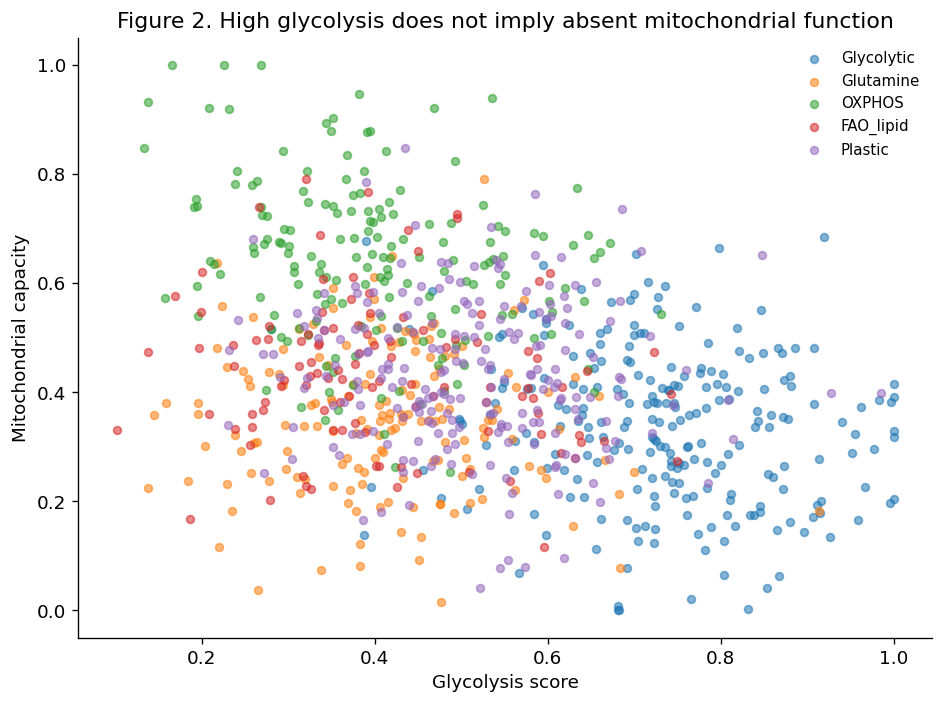

In [6]:

# Figure 2: glycolysis and mitochondrial capacity coexistence
sample = df.sample(900, random_state=SEED)
plt.figure(figsize=(8, 6))
for p in phenotypes:
    d = sample[sample["phenotype"] == p]
    plt.scatter(d["glycolysis_score"], d["mitochondrial_capacity"], s=22, alpha=0.55, label=p)
plt.xlabel("Glycolysis score")
plt.ylabel("Mitochondrial capacity")
plt.title("Figure 2. High glycolysis does not imply absent mitochondrial function")
plt.legend(frameon=False, fontsize=9)
savefig("figure_02_glycolysis_vs_mitochondria")



**Figure 2 implication.** The simulated cloud is intentionally non-binary. Warburg-like glycolysis and mitochondrial competence can coexist, reflecting modern cancer-metabolism biology rather than the historical “damaged mitochondria only” interpretation.



## 3. Define abstract metabolic-pressure scenarios

These are **not diets or drug regimens**. They are computational perturbations used to test principles.

- **Glucose pressure:** partially constrains glycolytic fuel.
- **Methionine/one-carbon pressure:** constrains biosynthetic and redox support.
- **OXPHOS pressure:** constrains mitochondrial oxidative contribution.
- **Global restriction:** weakly constrains all fuels but imposes a substantial host cost; this represents the conceptual problem with nonspecific starvation.
- **Fixed double bind:** concurrently constrains glucose/glycolysis and glutamine with partial lactate-shuttle pressure.
- **Adaptive double bind:** identifies each tumour's top two dependencies and constrains those two, representing precision metabolic phenotyping.
- **Adaptive double bind + host support:** same tumour pressure plus an abstract exercise/host-fitness support term.

The model evaluates two quantities:

\[
\text{Tumour suppression}=1-\text{relative tumour viability}
\]

\[
\text{Therapeutic window}=\text{tumour suppression}-\text{host cost}
\]

A strategy is attractive only if it suppresses the tumour **without imposing equal or greater cost on the host**.


In [7]:

fuel_order = ["glucose_dep", "glutamine_dep", "oxphos_dep", "fatty_acid_dep"]

def tumour_viability(row, residual, one_carbon=1.0, lactate_residual=1.0):
    dep = np.array([row[c] for c in fuel_order], dtype=float)
    residual = np.array(residual, dtype=float)

    direct_fuel = float(np.dot(dep, residual))
    blocked_fraction = max(0.0, 1.0 - direct_fuel)

    # Plastic tumours recover part of lost fuel access through rerouting.
    # Lactate-shuttle inhibition reduces this recovery.
    rerouting = row["plasticity"] * 0.34 * blocked_fraction
    rerouting *= (0.60 + 0.40*lactate_residual)
    fuel_available = np.clip(direct_fuel + rerouting, 0, 1)

    # Methionine/one-carbon pressure affects biomass and redox, not just ATP.
    biosynthesis = np.clip(
        1 - row["methionine_dependence"]*(1-one_carbon) * (0.55 + 0.25*row["biosynthetic_demand"]),
        0, 1
    )
    redox = np.clip(
        1 - row["methionine_dependence"]*(1-one_carbon) * (0.30 + 0.35*row["redox_demand"]),
        0, 1
    )

    # Apoptosis resistance leaves a residual survival term.
    death_resistance = 0.70 + 0.30*row["apoptosis_resistance"]

    viability = (
        0.46*fuel_available
        + 0.22*biosynthesis
        + 0.16*redox
        + 0.16*death_resistance
    )
    return np.clip(viability, 0, 1.15)

def host_cost(row, fuel_pressure=0.0, protein_pressure=0.0, mitochondrial_pressure=0.0, host_support=0.0):
    vulnerability = (
        0.42*row["cachexia_vulnerability"]
        + 0.28*(1-row["nutritional_reserve"])
        + 0.18*(1-row["fitness_index"])
        + 0.12*(1-row["insulin_sensitivity"])
    )
    cost = (
        fuel_pressure*(0.12 + 0.18*vulnerability)
        + protein_pressure*(0.10 + 0.28*vulnerability)
        + mitochondrial_pressure*(0.18 + 0.24*vulnerability)
        - host_support*(0.08 + 0.05*row["fitness_index"])
    )
    return float(np.clip(cost, -0.12, 0.75))

def apply_scenario(row, scenario):
    # residuals correspond to glucose, glutamine, OXPHOS, fatty acids
    if scenario == "Baseline":
        residual = [1, 1, 1, 1]
        one_carbon, lact = 1.0, 1.0
        cost = 0.0

    elif scenario == "Glucose pressure":
        residual = [0.52, 1, 1, 1]
        one_carbon, lact = 1.0, 1.0
        cost = host_cost(row, fuel_pressure=0.25)

    elif scenario == "Methionine pressure":
        residual = [1, 1, 1, 1]
        one_carbon, lact = 0.58, 1.0
        cost = host_cost(row, protein_pressure=0.28)

    elif scenario == "OXPHOS pressure":
        residual = [1, 1, 0.52, 1]
        one_carbon, lact = 1.0, 1.0
        cost = host_cost(row, mitochondrial_pressure=0.42)

    elif scenario == "Global restriction":
        residual = [0.72, 0.72, 0.72, 0.72]
        one_carbon, lact = 0.78, 0.90
        cost = host_cost(row, fuel_pressure=0.65, protein_pressure=0.45, mitochondrial_pressure=0.10)

    elif scenario == "Fixed double bind":
        residual = [0.58, 0.58, 1.0, 1.0]
        one_carbon, lact = 0.88, 0.68
        cost = host_cost(row, fuel_pressure=0.38, protein_pressure=0.08)

    elif scenario in ["Adaptive double bind", "Adaptive double bind + host support"]:
        deps = np.array([row[c] for c in fuel_order])
        residual = np.ones(4)
        top2 = np.argsort(deps)[-2:]
        residual[top2] = 0.56
        one_carbon = 0.86 if row["methionine_dependence"] > 0.70 else 1.0
        lact = 0.72 if row["lactate_shuttle"] > 0.65 else 1.0
        support = 0.0 if scenario == "Adaptive double bind" else 0.70
        cost = host_cost(row, fuel_pressure=0.30, protein_pressure=0.06, host_support=support)

    else:
        raise ValueError(scenario)

    viability = tumour_viability(row, residual, one_carbon=one_carbon, lactate_residual=lact)

    # Normalize every perturbation to the same virtual tumour's untreated state.
    # This makes Baseline suppression exactly zero and avoids conflating
    # intrinsic apoptosis resistance with intervention-induced suppression.
    baseline_viability = tumour_viability(
        row, [1.0, 1.0, 1.0, 1.0], one_carbon=1.0, lactate_residual=1.0
    )
    relative_viability = viability / baseline_viability
    suppression = np.clip(1 - relative_viability, -0.15, 1)
    window = suppression - cost
    return relative_viability, suppression, cost, window

scenarios = [
    "Baseline",
    "Glucose pressure",
    "Methionine pressure",
    "OXPHOS pressure",
    "Global restriction",
    "Fixed double bind",
    "Adaptive double bind",
    "Adaptive double bind + host support",
]

records = []
for idx, row in df.iterrows():
    for sc in scenarios:
        v, s, hc, tw = apply_scenario(row, sc)
        records.append([idx, sc, v, s, hc, tw])

res = pd.DataFrame(records, columns=[
    "virtual_subject","scenario","tumour_viability","tumour_suppression","host_cost","therapeutic_window"
])
res = res.merge(df[["phenotype","plasticity","cachexia_vulnerability"]], left_on="virtual_subject", right_index=True)
res.head()


,virtual_subject,scenario,tumour_viability,tumour_suppression,host_cost,therapeutic_window,phenotype,plasticity,cachexia_vulnerability
0,0,Baseline,1.000000,0.000000,0.000000,0.000000,Plastic,0.905465,0.322827
1,0,Glucose pressure,0.944672,0.055328,0.049514,0.005815,Plastic,0.905465,0.322827
2,0,Methionine pressure,0.907375,0.092625,0.061997,0.030628,Plastic,0.905465,0.322827
3,0,OXPHOS pressure,0.981906,0.018094,0.119310,-0.101217,Plastic,0.905465,0.322827
4,0,Global restriction,0.860077,0.139923,0.256780,-0.116857,Plastic,0.905465,0.322827


In [8]:

summary = (
    res.groupby("scenario")[["tumour_suppression","host_cost","therapeutic_window"]]
    .agg(["mean","median","std"])
)
summary


tumour_suppression  ... therapeutic_window
                                                  mean  ...                std
scenario                                                ...                   
Adaptive double bind                          0.129367  ...           0.026030
Adaptive double bind + host support           0.129367  ...           0.027677
Baseline                                      0.000000  ...           0.000000
Fixed double bind                             0.095771  ...           0.038181
Global restriction                            0.127830  ...           0.029805
Glucose pressure                              0.045547  ...           0.037150
Methionine pressure                           0.058439  ...           0.022778
OXPHOS pressure                               0.044755  ...           0.033722

[8 rows x 9 columns]

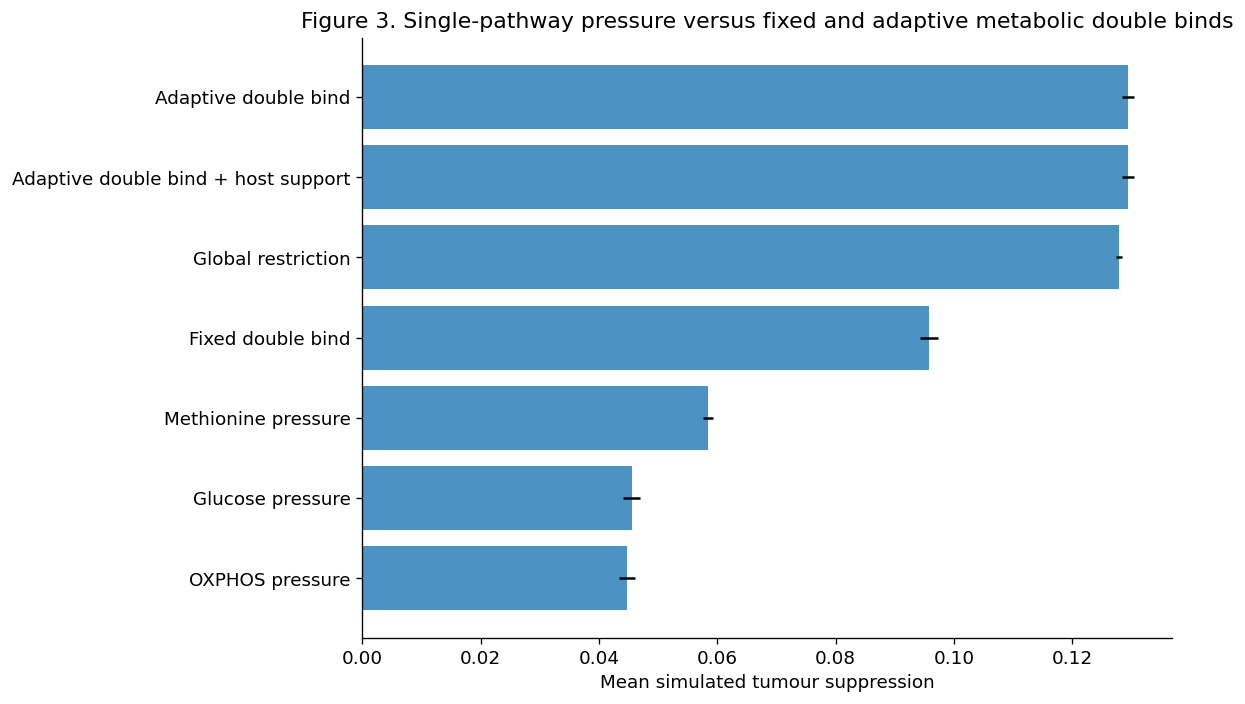

In [9]:

# Figure 3: scenario-level tumour suppression
plot_df = res[res["scenario"] != "Baseline"].groupby("scenario")["tumour_suppression"].agg(["mean","sem"]).sort_values("mean")
plt.figure(figsize=(10, 6))
plt.barh(plot_df.index, plot_df["mean"], xerr=1.96*plot_df["sem"], alpha=0.8)
plt.xlabel("Mean simulated tumour suppression")
plt.ylabel("")
plt.title("Figure 3. Single-pathway pressure versus fixed and adaptive metabolic double binds")
savefig("figure_03_scenario_tumour_suppression")


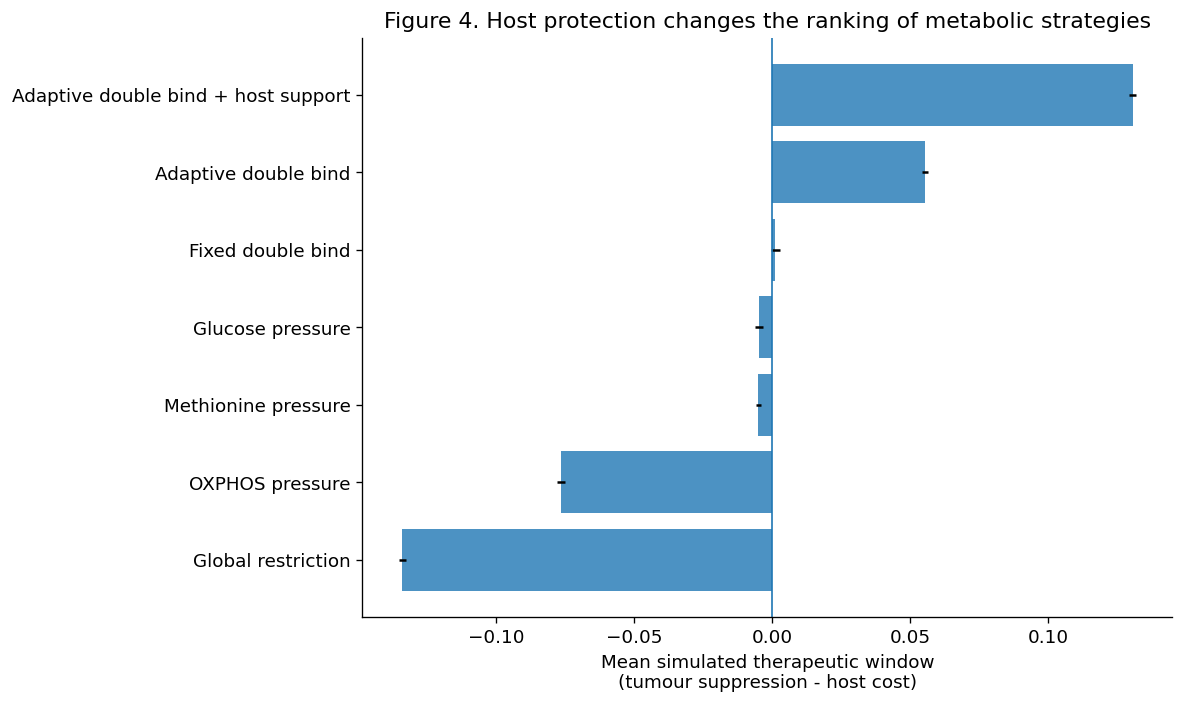

In [10]:

# Figure 4: therapeutic window
tw = res[res["scenario"] != "Baseline"].groupby("scenario")["therapeutic_window"].agg(["mean","sem"]).sort_values("mean")
plt.figure(figsize=(10, 6))
plt.barh(tw.index, tw["mean"], xerr=1.96*tw["sem"], alpha=0.8)
plt.axvline(0, linewidth=1)
plt.xlabel("Mean simulated therapeutic window\n(tumour suppression - host cost)")
plt.ylabel("")
plt.title("Figure 4. Host protection changes the ranking of metabolic strategies")
savefig("figure_04_therapeutic_window")



### Interpretation of Figures 3–4

The useful comparison is not simply “which scenario suppresses the tumour most?” It is “which scenario creates the largest **tumour-host asymmetry**?”

The deliberately harsh **global restriction** condition illustrates why nonspecific starvation can be a poor systems-level strategy: tumour metabolism is constrained, but the host also pays a large metabolic cost. By contrast, the adaptive double-bind concept aims to increase selectivity by constraining the tumour's highest dependencies while preserving host fitness.

This is a **hypothesis generated by the model**, not evidence that any particular dietary or pharmacological combination is safe or effective.


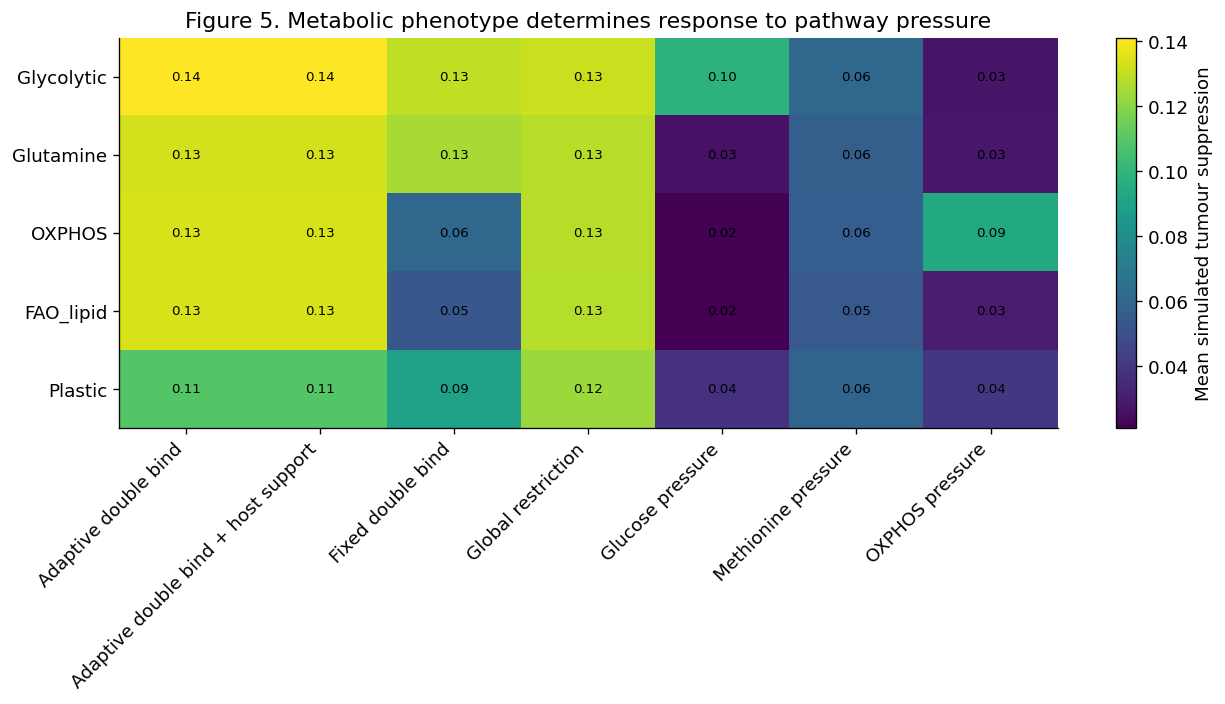

In [11]:

# Figure 5: phenotype × scenario response heatmap
heat = (
    res[~res["scenario"].isin(["Baseline"])]
    .pivot_table(index="phenotype", columns="scenario", values="tumour_suppression", aggfunc="mean")
    .reindex(phenotypes)
)
plt.figure(figsize=(11, 6))
im = plt.imshow(heat.values, aspect="auto")
plt.colorbar(im, label="Mean simulated tumour suppression")
plt.xticks(np.arange(len(heat.columns)), heat.columns, rotation=45, ha="right")
plt.yticks(np.arange(len(heat.index)), heat.index)
plt.title("Figure 5. Metabolic phenotype determines response to pathway pressure")
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        plt.text(j, i, f"{heat.iloc[i,j]:.2f}", ha="center", va="center", fontsize=8)
savefig("figure_05_phenotype_response_heatmap")



**Figure 5 implication.** A glucose-centred intervention is expected to perform best in glycolytic tumours and worse in OXPHOS-, fatty-acid-, glutamine-dependent or highly plastic tumours. Precision metabolic phenotyping is therefore a core prediction of this framework.



## 4. Test the metabolic-plasticity escape hypothesis

If plasticity is an escape mechanism, then **among tumours that are meaningfully glucose-dependent**, the same glucose pressure should become less effective as fuel flexibility increases. Conditioning on glucose dependence avoids confounding the escape question with tumours that were never strongly glucose-dependent in the first place.


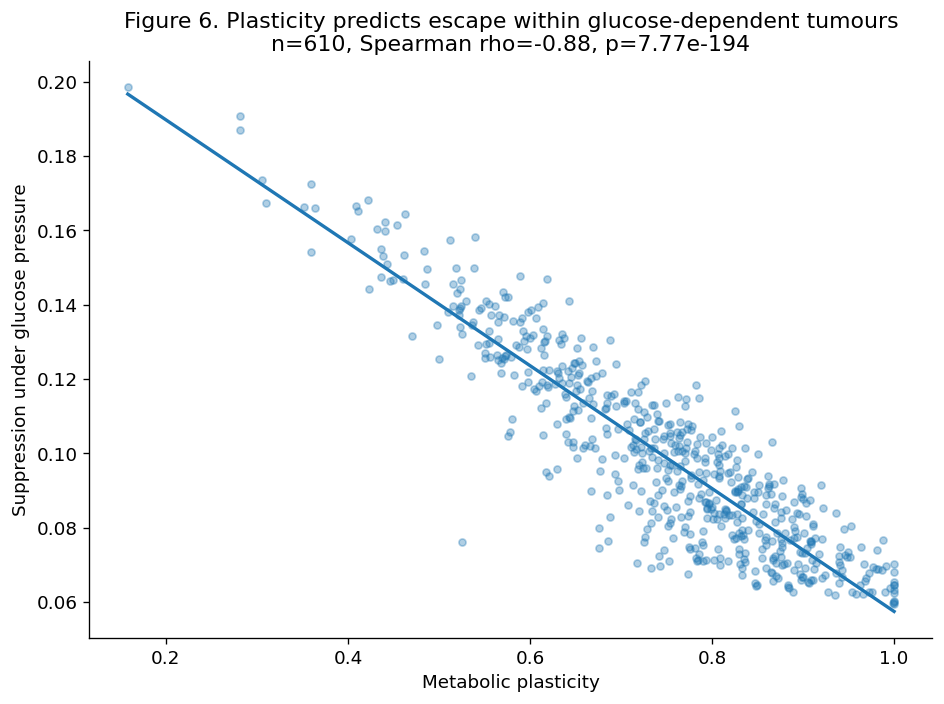

Glucose-dependent stratum n = 610
Spearman rho = -0.875, p = 7.772e-194


In [12]:
# Figure 6: metabolic plasticity as an escape mechanism within glucose-dependent tumours
gp = res[res["scenario"] == "Glucose pressure"].copy()
gp = gp.merge(
    df[["glucose_dep"]], left_on="virtual_subject", right_index=True, how="left"
)

# Pre-specified mechanistic stratum: tumours with substantial glucose dependency.
gp_high = gp[gp["glucose_dep"] > 0.40].copy()

rho, pval = stats.spearmanr(gp_high["plasticity"], gp_high["tumour_suppression"])

plt.figure(figsize=(8, 6))
plt.scatter(gp_high["plasticity"], gp_high["tumour_suppression"], s=18, alpha=0.35)
m, b = np.polyfit(gp_high["plasticity"], gp_high["tumour_suppression"], 1)
xx = np.linspace(gp_high["plasticity"].min(), gp_high["plasticity"].max(), 100)
plt.plot(xx, m*xx+b, linewidth=2)
plt.xlabel("Metabolic plasticity")
plt.ylabel("Suppression under glucose pressure")
plt.title(
    f"Figure 6. Plasticity predicts escape within glucose-dependent tumours\n"
    f"n={len(gp_high)}, Spearman rho={rho:.2f}, p={pval:.2e}"
)
savefig("figure_06_plasticity_escape")

print(f"Glucose-dependent stratum n = {len(gp_high)}")
print(f"Spearman rho = {rho:.3f}, p = {pval:.3e}")



### Interpretation

A negative relationship supports the conceptual claim that **fuel switching can defeat a single-fuel strategy**. The biological prediction is experimentally testable using isotope tracing, extracellular flux measurements and longitudinal metabolomics after selective pathway perturbation.



## 5. Demonstrate that respiratory competence and apoptosis resistance are distinct axes

Mitochondrial respiration and mitochondrial apoptosis are related but not equivalent. A cancer cell can maintain OXPHOS while resisting intrinsic apoptosis through BCL-2-family rewiring.


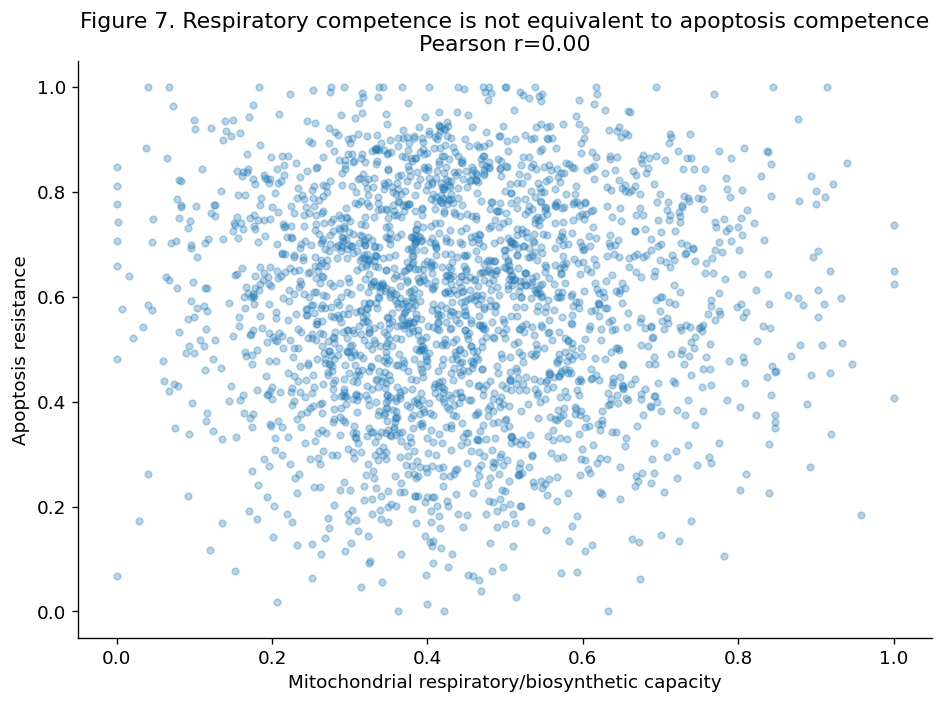

Pearson r = 0.002, p = 9.032e-01


In [13]:

r, p = stats.pearsonr(df["mitochondrial_capacity"], df["apoptosis_resistance"])

plt.figure(figsize=(8, 6))
plt.scatter(df["mitochondrial_capacity"], df["apoptosis_resistance"], s=16, alpha=0.30)
plt.xlabel("Mitochondrial respiratory/biosynthetic capacity")
plt.ylabel("Apoptosis resistance")
plt.title(f"Figure 7. Respiratory competence is not equivalent to apoptosis competence\nPearson r={r:.2f}")
savefig("figure_07_mitochondria_vs_apoptosis")

print(f"Pearson r = {r:.3f}, p = {p:.3e}")



**Figure 7 implication.** “Restoring mitochondrial health” is too nonspecific as a cancer hypothesis. The molecular programme controlling respiratory metabolism must be distinguished from the BAX/BAK, BCL-2, MCL1 and mitochondrial outer-membrane permeabilization machinery controlling intrinsic apoptosis.



## 6. Host metabolic reserve and the danger of nonspecific restriction

Here we test whether global nutrient pressure becomes increasingly unattractive as cachexia vulnerability rises.


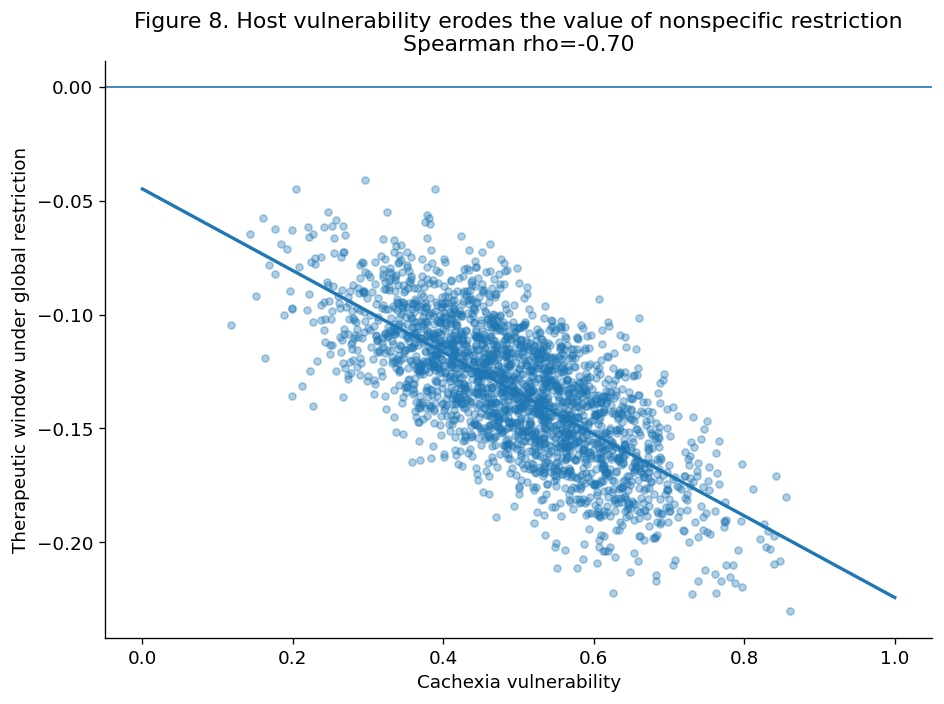

Spearman rho = -0.704, p = 0.000e+00


In [14]:

gr = res[res["scenario"] == "Global restriction"].copy()
r_cachex, p_cachex = stats.spearmanr(gr["cachexia_vulnerability"], gr["therapeutic_window"])

plt.figure(figsize=(8, 6))
plt.scatter(gr["cachexia_vulnerability"], gr["therapeutic_window"], s=18, alpha=0.35)
m, b = np.polyfit(gr["cachexia_vulnerability"], gr["therapeutic_window"], 1)
xx = np.linspace(0, 1, 100)
plt.plot(xx, m*xx+b, linewidth=2)
plt.axhline(0, linewidth=1)
plt.xlabel("Cachexia vulnerability")
plt.ylabel("Therapeutic window under global restriction")
plt.title(f"Figure 8. Host vulnerability erodes the value of nonspecific restriction\nSpearman rho={r_cachex:.2f}")
savefig("figure_08_cachexia_global_restriction")

print(f"Spearman rho = {r_cachex:.3f}, p = {p_cachex:.3e}")



### Interpretation

This simulation formalizes the systems-level objection to “starve the cancer” as a universal strategy. The host is not metabolically passive. Skeletal muscle, liver, immune cells and normal proliferating tissues require substrates, redox capacity and biosynthetic precursors. A cancer-metabolism strategy that worsens sarcopenia or cachexia may shrink the therapeutic window even if it creates tumour metabolic stress.



## 7. Unsupervised metabolic phenotyping

A future precision-metabolism workflow could combine transcriptomics, metabolomics, isotope tracing and extracellular flux measurements. Here, PCA and K-means are used only to illustrate the concept.


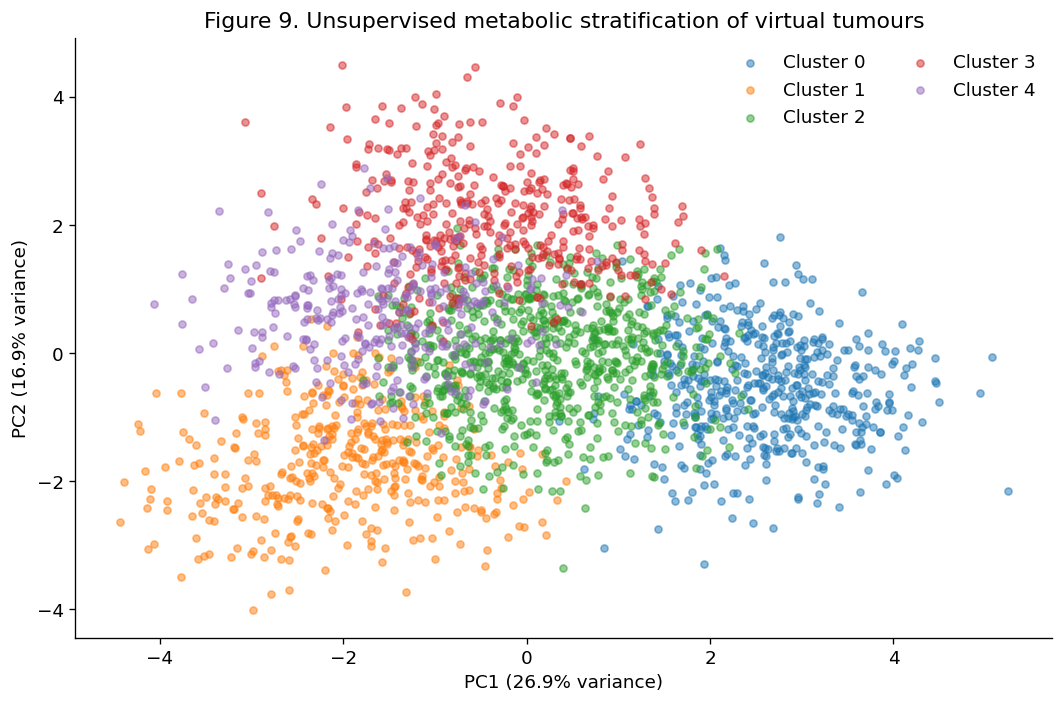

In [15]:

features = [
    "glucose_dep","glutamine_dep","oxphos_dep","fatty_acid_dep",
    "plasticity","mitochondrial_capacity","glycolysis_score",
    "lactate_shuttle","methionine_dependence","redox_demand",
    "biosynthetic_demand","apoptosis_resistance"
]
X = StandardScaler().fit_transform(df[features])
pca = PCA(n_components=2, random_state=SEED)
pcs = pca.fit_transform(X)

kmeans = KMeans(n_clusters=5, random_state=SEED, n_init=20)
cluster = kmeans.fit_predict(X)
df["metabolic_cluster"] = cluster

plt.figure(figsize=(9, 6))
for c in sorted(np.unique(cluster)):
    mask = cluster == c
    plt.scatter(pcs[mask,0], pcs[mask,1], s=18, alpha=0.5, label=f"Cluster {c}")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("Figure 9. Unsupervised metabolic stratification of virtual tumours")
plt.legend(frameon=False, ncol=2)
savefig("figure_09_pca_metabolic_clusters")


In [16]:

cluster_profile = df.groupby("metabolic_cluster")[features].mean().round(3)
cluster_profile


,glucose_dep,glutamine_dep,oxphos_dep,fatty_acid_dep,plasticity,mitochondrial_capacity,glycolysis_score,lactate_shuttle,methionine_dependence,redox_demand,biosynthetic_demand,apoptosis_resistance
metabolic_cluster,,,,,,,,,,,,
0,0.613,0.138,0.155,0.094,0.712,0.317,0.768,0.742,0.634,0.574,0.581,0.587
1,0.121,0.151,0.597,0.131,0.729,0.677,0.375,0.533,0.589,0.545,0.452,0.597
2,0.261,0.251,0.271,0.218,0.929,0.445,0.535,0.702,0.607,0.517,0.528,0.587
3,0.157,0.571,0.161,0.111,0.756,0.328,0.400,0.539,0.582,0.417,0.577,0.582
4,0.122,0.134,0.183,0.561,0.753,0.444,0.373,0.529,0.590,0.414,0.443,0.570



## 8. Machine-learning proof of concept: predict who benefits from adaptive double-bind pressure

A synthetic “responder” is defined as a tumour with adaptive-double-bind suppression above the cohort median. This is intentionally relative, avoiding a fabricated clinical response threshold.

The purpose is to demonstrate a future workflow:

**metabolic measurements → dependency features → response prediction → prospective experimental validation**


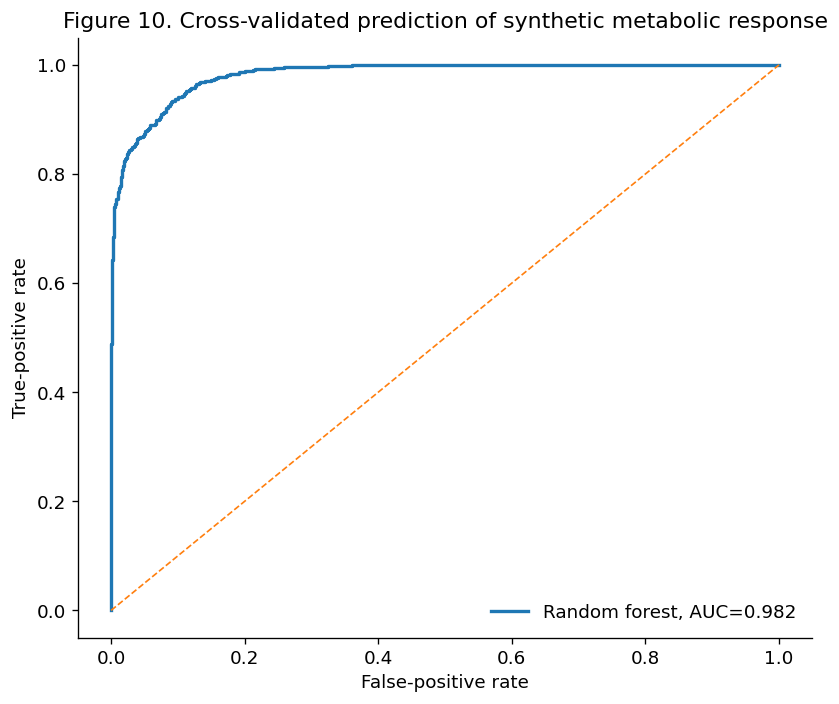

Cross-validated ROC-AUC: 0.982


In [17]:

adb = res[res["scenario"] == "Adaptive double bind"].set_index("virtual_subject")
ml = df[features].copy()
ml["response"] = (adb["tumour_suppression"] > adb["tumour_suppression"].median()).astype(int).values

X_ml = ml[features]
y_ml = ml["response"]

rf = RandomForestClassifier(
    n_estimators=500,
    min_samples_leaf=4,
    random_state=SEED,
    class_weight="balanced"
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
prob = cross_val_predict(rf, X_ml, y_ml, cv=cv, method="predict_proba")[:,1]
auc = roc_auc_score(y_ml, prob)
fpr, tpr, _ = roc_curve(y_ml, prob)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, linewidth=2, label=f"Random forest, AUC={auc:.3f}")
plt.plot([0,1],[0,1], linestyle="--", linewidth=1)
plt.xlabel("False-positive rate")
plt.ylabel("True-positive rate")
plt.title("Figure 10. Cross-validated prediction of synthetic metabolic response")
plt.legend(frameon=False)
savefig("figure_10_ml_roc")

print(f"Cross-validated ROC-AUC: {auc:.3f}")


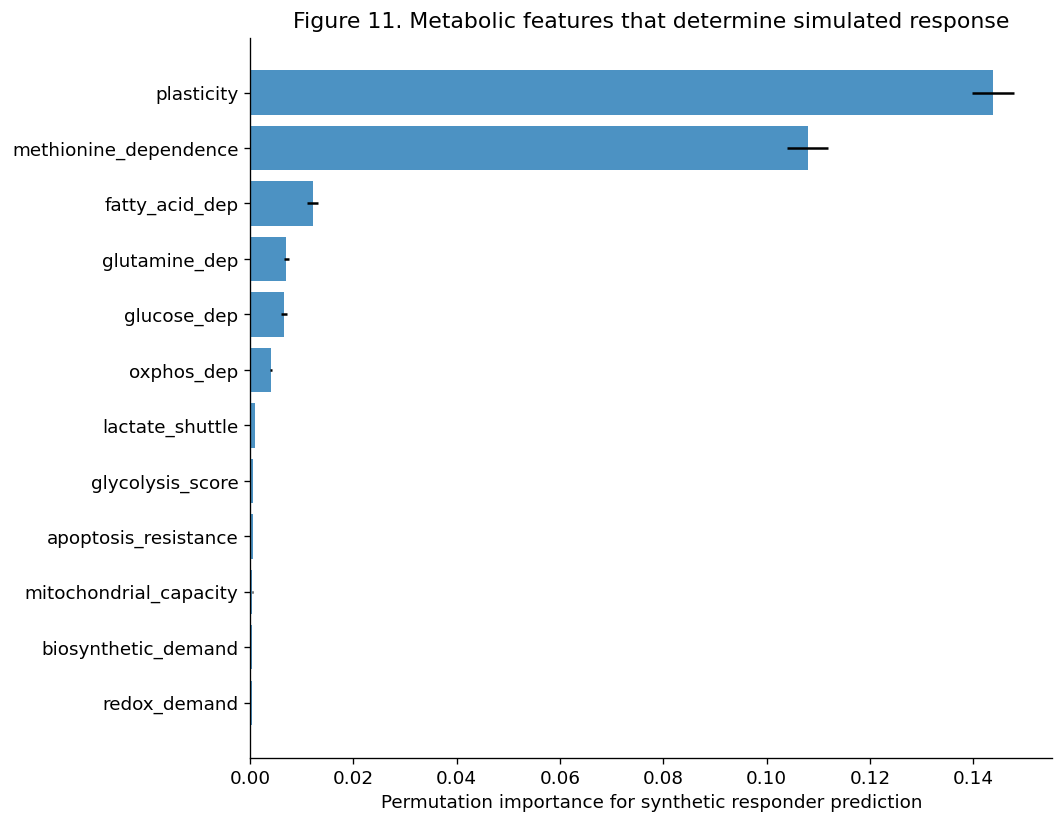

,feature,importance,sd
4,plasticity,0.143813,0.004126
8,methionine_dependence,0.107917,0.003977
3,fatty_acid_dep,0.012078,0.000994
1,glutamine_dep,0.006982,0.000513
0,glucose_dep,0.006566,0.000642
2,oxphos_dep,0.004032,0.000208
7,lactate_shuttle,0.000928,0.000066
6,glycolysis_score,0.000538,0.000032


In [18]:

rf.fit(X_ml, y_ml)
perm = permutation_importance(rf, X_ml, y_ml, n_repeats=15, random_state=SEED, scoring="roc_auc")
importance = pd.DataFrame({
    "feature": features,
    "importance": perm.importances_mean,
    "sd": perm.importances_std
}).sort_values("importance", ascending=True)

plt.figure(figsize=(9, 7))
plt.barh(importance["feature"], importance["importance"], xerr=importance["sd"], alpha=0.8)
plt.xlabel("Permutation importance for synthetic responder prediction")
plt.ylabel("")
plt.title("Figure 11. Metabolic features that determine simulated response")
savefig("figure_11_feature_importance")

importance.sort_values("importance", ascending=False).head(8)



### Interpretation

High predictive performance in a synthetic model is **not evidence of clinical predictability**. It simply verifies that the computational framework contains recoverable biological structure. In real research, the equivalent model would require external validation against experimentally measured response data from tumour cells, organoids, xenografts, prospective metabolomics, or clinical cohorts.



## 9. Sensitivity analysis: how strongly must two dominant fuels be constrained?

This grid analysis varies the residual availability of the two highest tumour dependencies from 0.45 to 0.90. Lower residual availability represents stronger abstract pressure. The objective is to identify whether the *principle* of simultaneous multi-pathway constraint is robust across plausible model strengths.


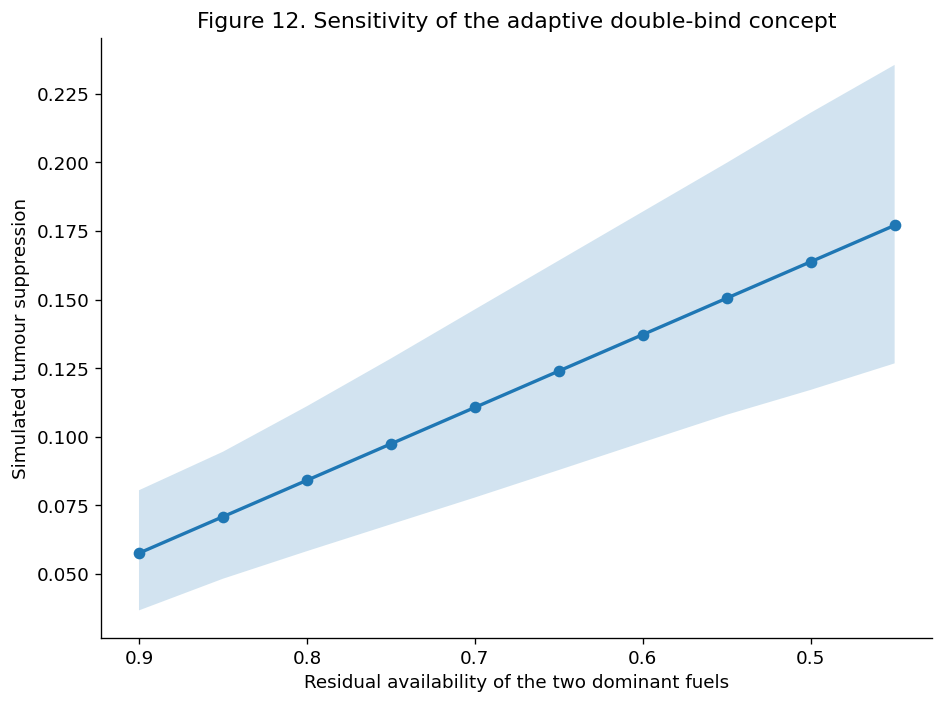

,residual_availability,mean_suppression,p2_5,p97_5
0,0.45,0.177041,0.126727,0.235549
1,0.50,0.163764,0.117063,0.218102
2,0.55,0.150488,0.108005,0.199838
3,0.60,0.137211,0.097963,0.182041
4,0.65,0.123935,0.087852,0.164218
5,0.70,0.110658,0.077826,0.146399
6,0.75,0.097381,0.068067,0.128500
7,0.80,0.084105,0.058279,0.111108
8,0.85,0.070828,0.048220,0.094517
9,0.90,0.057552,0.036676,0.080479


In [19]:

levels = np.linspace(0.45, 0.90, 10)
sens_records = []

sample_idx = rng.choice(df.index, size=700, replace=False)
for residual_level in levels:
    vals = []
    for idx in sample_idx:
        row = df.loc[idx]
        deps_i = np.array([row[c] for c in fuel_order])
        residual = np.ones(4)
        residual[np.argsort(deps_i)[-2:]] = residual_level
        v = tumour_viability(row, residual, one_carbon=0.92, lactate_residual=0.85)
        vals.append(1-v)
    sens_records.append([residual_level, np.mean(vals), np.percentile(vals, 2.5), np.percentile(vals, 97.5)])

sens = pd.DataFrame(sens_records, columns=["residual_availability","mean_suppression","p2_5","p97_5"])

plt.figure(figsize=(8, 6))
plt.plot(sens["residual_availability"], sens["mean_suppression"], marker="o", linewidth=2)
plt.fill_between(sens["residual_availability"], sens["p2_5"], sens["p97_5"], alpha=0.2)
plt.xlabel("Residual availability of the two dominant fuels")
plt.ylabel("Simulated tumour suppression")
plt.title("Figure 12. Sensitivity of the adaptive double-bind concept")
plt.gca().invert_xaxis()
savefig("figure_12_sensitivity_double_bind")

sens



## 10. Literature-anchored exercise benchmark

The CHALLENGE randomized trial is not evidence that exercise “starves cancer.” Its importance for this review is different: it demonstrates that **host physiology is an active determinant of outcome** and that an intervention improving systemic fitness can produce clinically meaningful benefit in a defined cancer population.

Published trial values:

- 5-year disease-free survival: **80.3% exercise vs 73.9% health-education control**
- 8-year overall survival: **90.3% exercise vs 83.2% control**
- PubMed: https://pubmed.ncbi.nlm.nih.gov/40450658/

The chart below reproduces these published percentages directly and keeps them separate from synthetic mechanistic outputs.


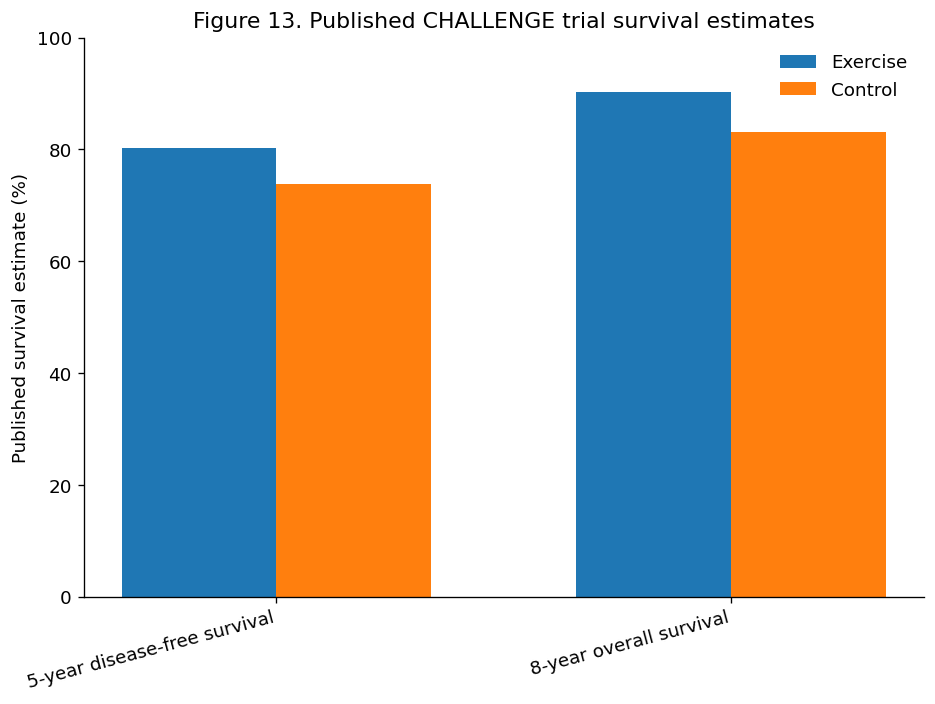

In [20]:

challenge = pd.DataFrame({
    "endpoint": ["5-year disease-free survival", "8-year overall survival"],
    "Exercise": [80.3, 90.3],
    "Control": [73.9, 83.2]
})

x = np.arange(len(challenge))
w = 0.34
plt.figure(figsize=(8, 6))
plt.bar(x-w/2, challenge["Exercise"], width=w, label="Exercise")
plt.bar(x+w/2, challenge["Control"], width=w, label="Control")
plt.xticks(x, challenge["endpoint"], rotation=15, ha="right")
plt.ylabel("Published survival estimate (%)")
plt.ylim(0, 100)
plt.title("Figure 13. Published CHALLENGE trial survival estimates")
plt.legend(frameon=False)
savefig("figure_13_challenge_trial_benchmark")



## 11. Statistical summary

Because the cohort is simulated and large, conventional p-values can become trivially small. Effect size and therapeutic-window differences are more informative here. We therefore report mean differences with bootstrap 95% confidence intervals.


In [21]:

def bootstrap_mean_diff(a, b, n_boot=3000, seed=SEED):
    rg = np.random.default_rng(seed)
    a = np.asarray(a); b = np.asarray(b)
    obs = a.mean() - b.mean()
    boot = []
    for _ in range(n_boot):
        aa = rg.choice(a, len(a), replace=True)
        bb = rg.choice(b, len(b), replace=True)
        boot.append(aa.mean() - bb.mean())
    lo, hi = np.percentile(boot, [2.5, 97.5])
    return obs, lo, hi

comparisons = [
    ("Adaptive double bind", "Glucose pressure"),
    ("Adaptive double bind + host support", "Global restriction"),
    ("Fixed double bind", "Glucose pressure"),
]

stats_rows = []
for a_name, b_name in comparisons:
    a = res[res["scenario"] == a_name]["therapeutic_window"]
    b = res[res["scenario"] == b_name]["therapeutic_window"]
    diff, lo, hi = bootstrap_mean_diff(a, b)
    stats_rows.append([a_name, b_name, diff, lo, hi])

stats_table = pd.DataFrame(stats_rows, columns=["Scenario A","Scenario B","Mean difference","CI_low","CI_high"])
stats_table


,Scenario A,Scenario B,Mean difference,CI_low,CI_high
0,Adaptive double bind,Glucose pressure,0.060154,0.058393,0.061954
1,Adaptive double bind + host support,Global restriction,0.264319,0.262699,0.265992
2,Fixed double bind,Glucose pressure,0.005915,0.003783,0.007997



## 12. Core proof-of-concept conclusions

The simulation is constructed to test several molecular and systems-level propositions that can later organize the review paper.

### Proposition 1 — Cancer metabolism is not simply “fermentation because mitochondria are broken”
High glycolytic flux and mitochondrial competence can coexist. Mitochondria remain important for TCA-cycle chemistry, redox balance, biosynthesis, signalling and, in many tumours, ATP production.

### Proposition 2 — ATP efficiency alone does not explain tumour metabolism
A proliferating cell must satisfy at least three simultaneous demands:

\[
\boxed{\text{ATP}+\text{reducing power}+\text{biosynthetic carbon/nitrogen}}
\]

A pathway that is inefficient for ATP per glucose molecule may still be advantageous if it supports rapid biomass generation and redox control.

### Proposition 3 — Single-fuel restriction invites metabolic escape
The model predicts that high metabolic plasticity reduces the effect of glucose-only pressure because cells can increase reliance on glutamine, OXPHOS, fatty acids or metabolite exchange.

### Proposition 4 — The tumour's dominant dependency and its escape route should both be identified
The adaptive double-bind model performs better than a universal fixed perturbation because it targets the top two dependencies of each virtual tumour.

### Proposition 5 — Host protection is part of the anticancer systems problem
A tumour-selective intervention is useful only if the host remains metabolically competent. Skeletal muscle, insulin sensitivity, mitochondrial function, immune competence and nutritional reserve therefore belong inside the model rather than being treated as background variables.

### Proposition 6 — Cachexia is a decisive boundary condition
The simulated therapeutic window of global restriction worsens as host vulnerability rises. This supports avoiding the assumption that stronger calorie or protein deprivation is automatically better.

### Proposition 7 — Mitochondrial respiration and mitochondrial apoptosis must be separated mechanistically
A tumour may retain oxidative metabolism while blocking BAX/BAK-dependent intrinsic apoptosis through BCL-2-family rewiring.

### Proposition 8 — Precision metabolic phenotyping is experimentally testable
A translational programme could combine:
- tumour and plasma metabolomics,
- stable-isotope tracing,
- Seahorse OCR/ECAR,
- transcriptomics/proteomics,
- GLUT1/HK2/LDHA/MCT1/MCT4,
- GLS1 and glutamine flux,
- CPT1A/FAO and lipid metabolism,
- ETC/OXPHOS measurements,
- one-carbon and methionine-cycle metabolites,
- BCL-2/MCL1/BAX/BAK pathway state,
- host lean mass and exercise capacity.

The output could be a patient- or tumour-specific **Metabolic Dependency Score** and experimentally validated map of primary and escape fuels.



## 13. Experimental programme suggested by the model

A rigorous future study could proceed from **in vitro mechanism → organoid validation → in vivo systems analysis → carefully designed clinical translation**.

1. Quantify basal OCR, ECAR, ATP-linked respiration, spare respiratory capacity and lactate production.
2. Perform U-\(^{13}\)C-glucose, U-\(^{13}\)C-glutamine and \(^{13}\)C-fatty-acid tracing.
3. Perturb one pathway at a time to measure compensatory flux.
4. Perturb the dominant pathway plus its experimentally observed escape pathway.
5. Quantify ATP, NADPH/NADP\(^+\), GSH/GSSG, nucleotide pools, one-carbon metabolites and apoptosis.
6. Repeat in matched tumour and non-malignant cells to estimate selectivity.
7. Repeat in patient-derived organoids and, where scientifically justified, animal models.
8. Integrate host muscle, systemic glucose/insulin, metabolomics and inflammatory/cachexia markers.
9. Train predictive models only after generating real response labels.
10. Externally validate before making any clinical claim.

This design turns the review's conceptual framework into falsifiable experiments rather than a dietary assertion.



## 14. References — peer-reviewed journals indexed in PubMed

1. Vander Heiden MG, Cantley LC, Thompson CB. Understanding the Warburg effect: the metabolic requirements of cell proliferation. *Science*. 2009;324:1029-1033. PMID: 19460998. https://pubmed.ncbi.nlm.nih.gov/19460998/
2. Tufail M, et al. Altered metabolism in cancer: insights into energy pathways and therapeutic targets. 2024. PMID: 39294640. https://pubmed.ncbi.nlm.nih.gov/39294640/
3. Masoudi M, et al. Metabolic adaptations in cancer stem cells: a key to therapy resistance. 2024. PMID: 38599259. https://pubmed.ncbi.nlm.nih.gov/38599259/
4. Semenza GL. Tumor metabolism: cancer cells give and take lactate. 2008. PMID: 19033652. https://pubmed.ncbi.nlm.nih.gov/19033652/
5. Draoui N, Feron O. Lactate shuttles at a glance: from physiological paradigms to anti-cancer treatments. 2011. PMID: 22065843. https://pubmed.ncbi.nlm.nih.gov/22065843/
6. Sullivan LB, et al. Supporting aspartate biosynthesis is an essential function of respiration in proliferating cells. *Cell*. 2015. PMID: 26232224. https://pubmed.ncbi.nlm.nih.gov/26232224/
7. Palominos C, et al. Mitochondrial bioenergetics as a cell fate rheostat for apoptosis. 2024. PMID: 38788967. https://pubmed.ncbi.nlm.nih.gov/38788967/
8. Gao X, et al. Dietary methionine influences therapy in mouse cancer models and alters human metabolism. *Nature*. 2019;572:397-401. PMID: 31367041. https://pubmed.ncbi.nlm.nih.gov/31367041/
9. Vernieri C, et al. Fasting-mimicking diet is safe and reshapes metabolism and antitumor immunity in patients with cancer. *Cancer Discovery*. 2022;12:90-107. PMID: 34789537. https://pubmed.ncbi.nlm.nih.gov/34789537/
10. Courneya KS, et al. Structured Exercise after Adjuvant Chemotherapy for Colon Cancer. *New England Journal of Medicine*. 2025. PMID: 40450658. https://pubmed.ncbi.nlm.nih.gov/40450658/
11. Baumert P, et al. Skeletal muscle hypertrophy rewires glucose metabolism: an experimental investigation and systematic review. *J Cachexia Sarcopenia Muscle*. 2024;15:989-1002. PMID: 38742477. https://pubmed.ncbi.nlm.nih.gov/38742477/
12. Shorter E, Engman V, Lanner JT. Cancer-associated muscle weakness - from triggers to molecular mechanisms. *Molecular Aspects of Medicine*. 2024;97:101260. PMID: 38457901. https://pubmed.ncbi.nlm.nih.gov/38457901/
13. Salido-Bueno B, et al. Effects of ketogenic diets on cancer-related variables: a systematic review and meta-analysis. 2024. PMID: 38923748. https://pubmed.ncbi.nlm.nih.gov/38923748/

### Reproducibility note
All random-number generation uses `SEED = 42`. The notebook exports the synthetic cohort, scenario-level results, summary statistics and publication-resolution figures.


In [22]:

# Export analysis-ready tables for the future review/manuscript.
df.to_csv(OUTPUT_DIR / "synthetic_tumour_host_cohort.csv", index=False)
res.to_csv(OUTPUT_DIR / "scenario_results_long.csv", index=False)
benchmarks.to_csv(OUTPUT_DIR / "literature_benchmark_map.csv", index=False)
stats_table.to_csv(OUTPUT_DIR / "bootstrap_comparisons.csv", index=False)
cluster_profile.to_csv(OUTPUT_DIR / "metabolic_cluster_profiles.csv")
sens.to_csv(OUTPUT_DIR / "double_bind_sensitivity.csv", index=False)

manifest = pd.DataFrame({
    "file": sorted([p.name for p in OUTPUT_DIR.iterdir()]),
})
display(manifest)

print("\nCompleted successfully.")
print("Synthetic data and publication figures were written to:", OUTPUT_DIR.resolve())


,file
0,bootstrap_comparisons.csv
1,double_bind_sensitivity.csv
2,figure_01_fuel_dependencies.pdf
3,figure_01_fuel_dependencies.png
4,figure_02_glycolysis_vs_mitochondria.pdf
5,figure_02_glycolysis_vs_mitochondria.png
6,figure_03_scenario_tumour_suppression.pdf
7,figure_03_scenario_tumour_suppression.png
8,figure_04_therapeutic_window.pdf
9,figure_04_therapeutic_window.png



Completed successfully.
Synthetic data and publication figures were written to: /mnt/data/cancer_metabolic_double_bind_outputs
